In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [2]:
# Load your model (keep your existing loading code)
model = models.vit_b_16(weights=None)
model.heads = nn.Linear(model.heads[0].in_features, 3)
model.load_state_dict(torch.load('potato_vit_fine_tuned.pth', map_location='cpu'))
model.eval()

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [3]:
# THIS IS THE KEY FIX - Monkey patch the attention mechanism
def patch_vit_attention(vit_model):
    """Patches the ViT model to return attention weights"""
    
    attentions_list = []
    
    # Store the original forward method
    original_forward = vit_model.encoder.layers[0].self_attention.forward
    
    def new_forward(self, query, key, value, need_weights=True, **kwargs):
        # Call original forward but force need_weights=True
        attn_output, attn_weights = original_forward(query, key, value, need_weights=True, **kwargs)
        # Store the attention weights
        attentions_list.append(attn_weights.detach().cpu())
        return attn_output, attn_weights
    
    # Apply the patch to all layers
    for layer in vit_model.encoder.layers:
        layer.self_attention.forward = new_forward.__get__(layer.self_attention, type(layer.self_attention))
    
    return attentions_list

In [4]:
# Apply the patch
attentions_list = patch_vit_attention(model)

In [5]:
# Load and preprocess image
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
#image_path = './dataset/Potato___Early_blight/0e0a1b51-f61c-4934-bc57-a820af1faacb___RS_Early.B_7147.JPG'
image_path = './dataset/Potato___Early_blight/0f9c098f-a6df-4a73-8c14-8e7d4dbb1b0b___RS_Early.B 7991.JPG'
#image_path = './dataset/Potato___Late_blight/1a5f4258-21df-4334-a933-2ef073c932ba___RS_LB 3089.JPG'
#image_path = './dataset/Potato___healthy/7bfda067-6e35-4af5-a9c4-4b3b5f357871___RS_HL 1813.JPG'
image = Image.open(image_path).convert('RGB')
input_tensor = preprocess(image).unsqueeze(0)

In [7]:
# Forward pass
with torch.no_grad():
    output = model(input_tensor)

In [8]:
print(f"Number of attention maps captured: {len(attentions_list)}")
if attentions_list:
    print(f"Attention weights shape: {attentions_list[0].shape}")

Number of attention maps captured: 12
Attention weights shape: torch.Size([1, 197, 197])


In [9]:
# First, inspect the actual shape of attention weights
print(f"Number of attention maps: {len(attentions_list)}")
print(f"Shape of first attention map: {attentions_list[0].shape}")
print(f"Shape of last attention map: {attentions_list[-1].shape}")

Number of attention maps: 12
Shape of first attention map: torch.Size([1, 197, 197])
Shape of last attention map: torch.Size([1, 197, 197])


In [10]:
# Check the dimensions
attn_sample = attentions_list[-1]
print(f"\nDetailed shape info:")
print(f"Tensor dimensions: {attn_sample.dim()}")
print(f"Full shape: {attn_sample.shape}")


Detailed shape info:
Tensor dimensions: 3
Full shape: torch.Size([1, 197, 197])


In [11]:
# Corrected visualization function for [batch, tokens, tokens] shape
def visualize_attention(attentions_list, image, layer_idx=-1):
    """
    Visualize attention map for a specific layer
    Attention shape: [1, 197, 197] where 197 = 1 CLS token + 196 patches (14x14 grid)
    """
    # Get attention weights for specified layer
    attn_weights = attentions_list[layer_idx]  # Shape: [1, 197, 197]
    
    # Remove batch dimension
    attn_weights = attn_weights[0]  # Shape: [197, 197]
    
    # Get attention from CLS token to all patches (excluding CLS to CLS)
    cls_attention = attn_weights[0, 1:]  # Shape: [196]
    
    # Reshape to 14x14 grid (since 14*14 = 196)
    grid_size = 14
    attention_map = cls_attention.reshape(grid_size, grid_size).numpy()
    
    # Normalize to [0, 1] for visualization
    attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
    
    # Resize to match original image size (224x224)
    attention_map_resized = cv2.resize(attention_map, (224, 224))
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    im = axes[1].imshow(attention_map, cmap='hot')
    axes[1].set_title(f'Attention Map (Layer {layer_idx})')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1])
    
    axes[2].imshow(image)
    axes[2].imshow(attention_map_resized, cmap='jet', alpha=0.5)
    axes[2].set_title('Attention Overlay')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return attention_map

Visualizing last layer attention:


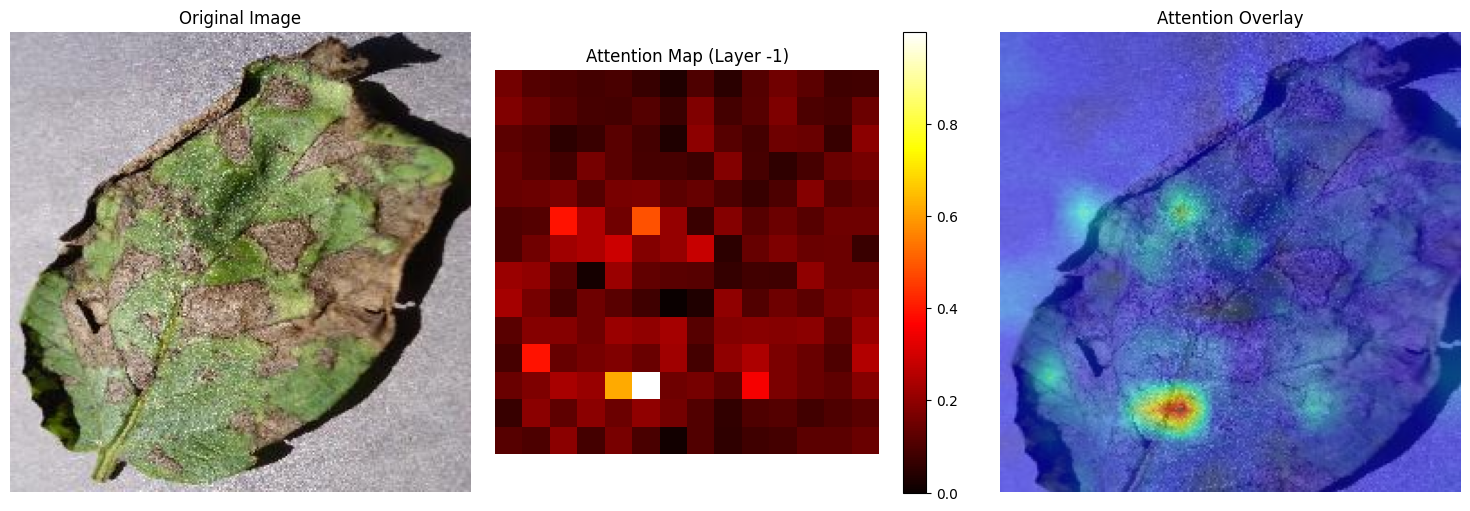

array([[0.15687208, 0.1111019 , 0.09920021, 0.08810866, 0.09576578,
        0.06733766, 0.0344474 , 0.10439548, 0.04928225, 0.11065669,
        0.15503448, 0.12139791, 0.08089079, 0.08326633],
       [0.17756835, 0.14119853, 0.11526408, 0.0911301 , 0.08828377,
        0.11257314, 0.07297339, 0.17790392, 0.08600715, 0.11642727,
        0.17200984, 0.09901509, 0.09138528, 0.14658852],
       [0.12456802, 0.10693023, 0.05443141, 0.07319397, 0.11904648,
        0.08902916, 0.03140421, 0.19554883, 0.11710018, 0.08950458,
        0.15178494, 0.14395872, 0.06899089, 0.19403774],
       [0.13831998, 0.11118613, 0.08463882, 0.16300076, 0.11869828,
        0.09281104, 0.08988916, 0.07665323, 0.1803563 , 0.09172219,
        0.05809672, 0.09107815, 0.14412856, 0.16323268],
       [0.1400682 , 0.14760506, 0.16439553, 0.10991037, 0.1640703 ,
        0.17005086, 0.1222564 , 0.13865915, 0.09831835, 0.0702548 ,
        0.09864867, 0.18582821, 0.11300284, 0.13412419],
       [0.10198476, 0.10966711, 0.3

In [12]:
# Visualize attention from different layers
print("Visualizing last layer attention:")
visualize_attention(attentions_list, image, layer_idx=-1)


Visualizing first layer attention:


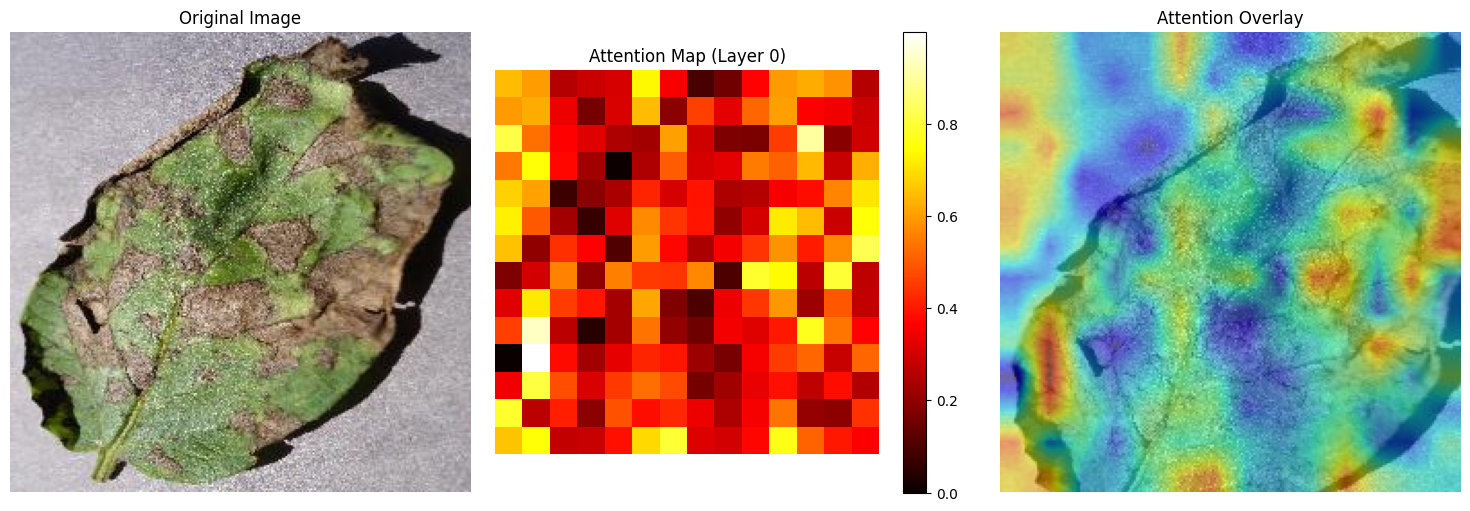

array([[0.6479357 , 0.59873   , 0.25432584, 0.2882738 , 0.30522957,
        0.7355723 , 0.3589204 , 0.09552982, 0.15297288, 0.36925247,
        0.5973717 , 0.6223366 , 0.5840344 , 0.2571006 ],
       [0.5952301 , 0.62317014, 0.3393206 , 0.16086066, 0.31056404,
        0.64676774, 0.1921616 , 0.46084797, 0.32453886, 0.51711214,
        0.6051889 , 0.36341092, 0.3468813 , 0.28831652],
       [0.8135459 , 0.5345539 , 0.36471352, 0.31773958, 0.24537618,
        0.22893615, 0.6021989 , 0.2965396 , 0.17196393, 0.17156853,
        0.45446685, 0.9039982 , 0.19051339, 0.2960874 ],
       [0.54440594, 0.7537126 , 0.3762466 , 0.22698842, 0.00503995,
        0.24928774, 0.50096405, 0.3063584 , 0.32557416, 0.55039346,
        0.50880516, 0.6419284 , 0.28235853, 0.62652117],
       [0.67817396, 0.6081742 , 0.07746529, 0.19376223, 0.2398114 ,
        0.42141354, 0.3055933 , 0.3931895 , 0.24357677, 0.25548878,
        0.3522618 , 0.38284072, 0.56485724, 0.7078405 ],
       [0.72417504, 0.49677333, 0.2

In [13]:
print("\nVisualizing first layer attention:")
visualize_attention(attentions_list, image, layer_idx=0)


Visualizing middle layer attention:


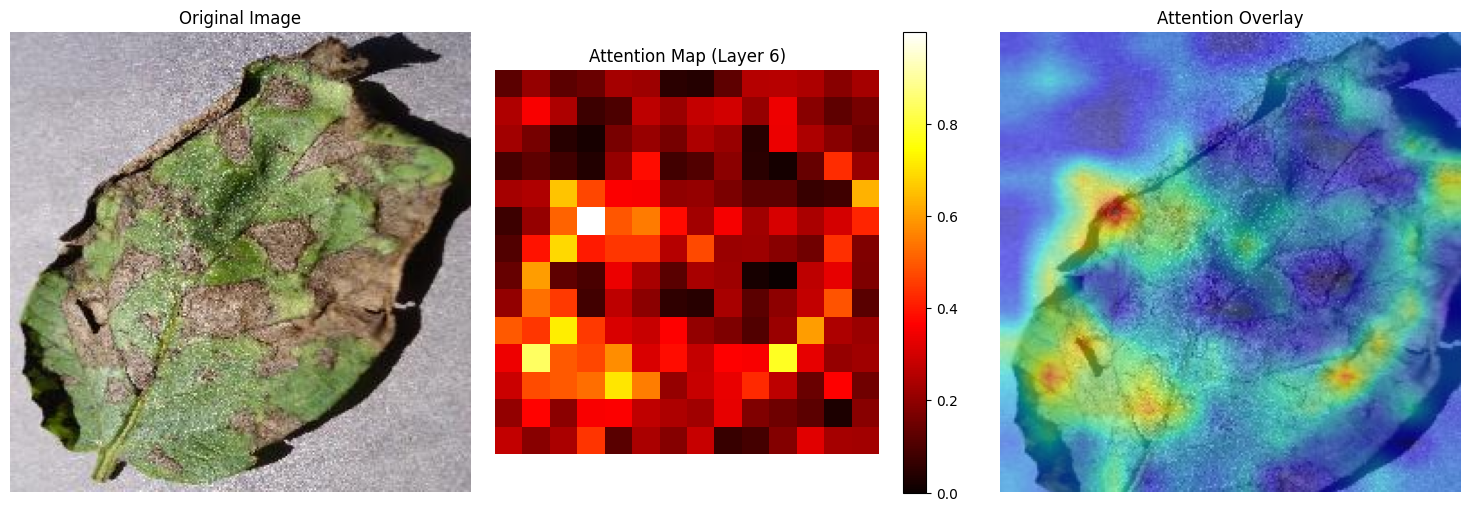

array([[0.12173465, 0.20790607, 0.12333395, 0.14115463, 0.23254754,
        0.22131856, 0.04919801, 0.04281325, 0.12857401, 0.25674435,
        0.2583887 , 0.24507967, 0.19032384, 0.23349334],
       [0.24774641, 0.3576315 , 0.24554105, 0.07504535, 0.0979956 ,
        0.2677482 , 0.2182018 , 0.27924824, 0.299988  , 0.20725194,
        0.3406653 , 0.19079427, 0.12843923, 0.16144948],
       [0.22914863, 0.16059837, 0.04573928, 0.02041962, 0.16568337,
        0.21151482, 0.16043454, 0.24407546, 0.21232986, 0.04437795,
        0.3384931 , 0.24491371, 0.18751319, 0.14601842],
       [0.09228503, 0.12810034, 0.08059711, 0.03564144, 0.20969951,
        0.38341147, 0.08563864, 0.10882849, 0.19355623, 0.04976542,
        0.01829211, 0.14055295, 0.43055815, 0.21274234],
       [0.23280996, 0.24830209, 0.65784734, 0.46978697, 0.36167026,
        0.357428  , 0.20041554, 0.21034552, 0.16894333, 0.12151752,
        0.12261007, 0.06782803, 0.08060195, 0.6313825 ],
       [0.07600177, 0.209606  , 0.5

In [14]:
print("\nVisualizing middle layer attention:")
visualize_attention(attentions_list, image, layer_idx=6)

### Compare attention across multiple layers:

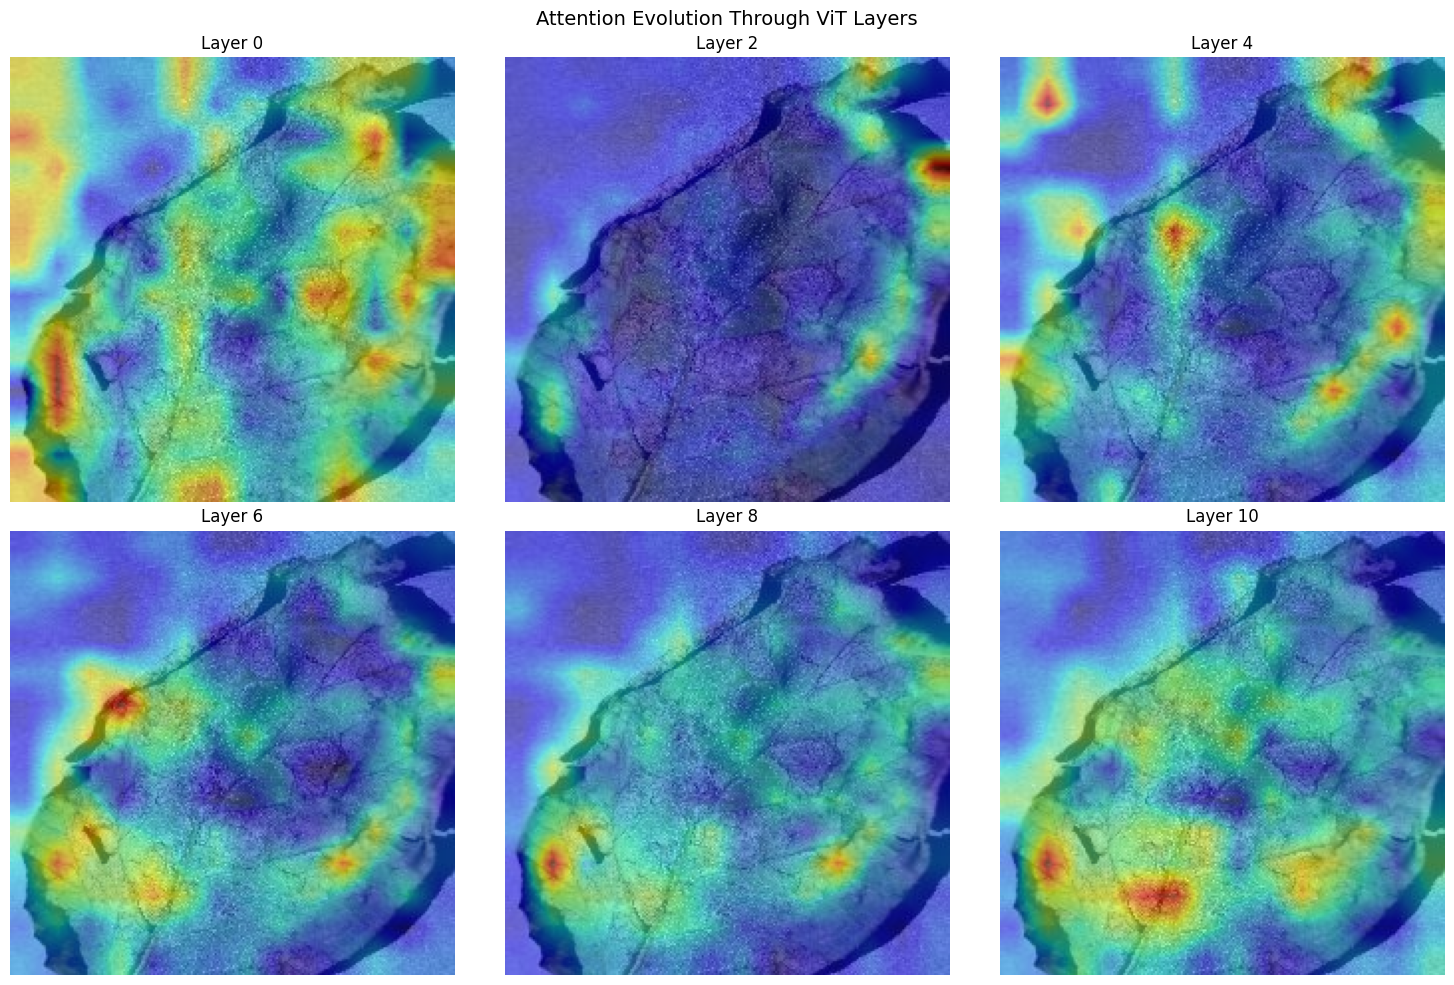

In [15]:
# Visualize attention progression through layers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
layer_indices = [0, 2, 4, 6, 8, 10]  # Select 6 different layers

for idx, layer_idx in enumerate(layer_indices):
    row = idx // 3
    col = idx % 3
    
    # Get attention for this layer
    attn_weights = attentions_list[layer_idx][0]  # [197, 197]
    cls_attention = attn_weights[0, 1:]  # [196]
    
    # Reshape to 14x14 grid
    attention_map = cls_attention.reshape(14, 14).numpy()
    
    # Normalize
    attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
    
    # Resize for overlay
    attention_map_resized = cv2.resize(attention_map, (224, 224))
    
    # Plot overlay on image
    axes[row, col].imshow(image)
    axes[row, col].imshow(attention_map_resized, cmap='jet', alpha=0.5)
    axes[row, col].set_title(f'Layer {layer_idx}')
    axes[row, col].axis('off')

plt.suptitle('Attention Evolution Through ViT Layers', fontsize=14)
plt.tight_layout()
plt.show()

### Analyze attention statistics:

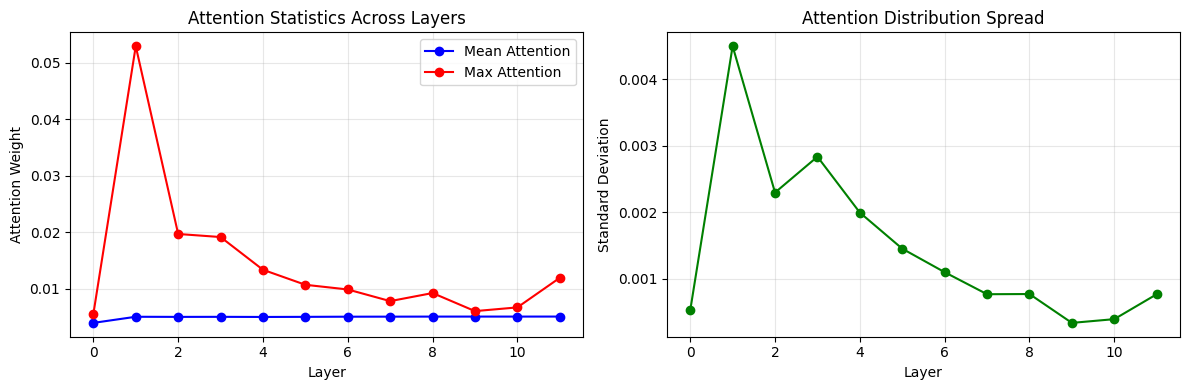


Top 10 most attended patches in final layer:
1. Patch (11, 5): attention weight = 0.0119
2. Patch (11, 4): attention weight = 0.0089
3. Patch (5, 5): attention weight = 0.0078
4. Patch (5, 2): attention weight = 0.0071
5. Patch (10, 1): attention weight = 0.0070
6. Patch (11, 9): attention weight = 0.0067
7. Patch (6, 4): attention weight = 0.0062
8. Patch (6, 7): attention weight = 0.0062
9. Patch (10, 13): attention weight = 0.0059
10. Patch (10, 9): attention weight = 0.0059


In [16]:
# Analyze how attention changes across layers
layer_attentions = []

for layer_idx in range(len(attentions_list)):
    attn_weights = attentions_list[layer_idx][0]  # [197, 197]
    cls_attention = attn_weights[0, 1:]  # [196]
    
    # Calculate statistics
    mean_attn = cls_attention.mean().item()
    max_attn = cls_attention.max().item()
    std_attn = cls_attention.std().item()
    
    layer_attentions.append({
        'layer': layer_idx,
        'mean': mean_attn,
        'max': max_attn,
        'std': std_attn
    })

# Plot attention statistics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

layers = [d['layer'] for d in layer_attentions]
means = [d['mean'] for d in layer_attentions]
maxs = [d['max'] for d in layer_attentions]
stds = [d['std'] for d in layer_attentions]

axes[0].plot(layers, means, 'b-o', label='Mean Attention')
axes[0].plot(layers, maxs, 'r-o', label='Max Attention')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Attention Weight')
axes[0].set_title('Attention Statistics Across Layers')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(layers, stds, 'g-o')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Standard Deviation')
axes[1].set_title('Attention Distribution Spread')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find which patches get the most attention in the final layer
final_attention = attentions_list[-1][0, 0, 1:]  # [196]
top_k = 10
top_patches = torch.topk(final_attention, top_k)

print(f"\nTop {top_k} most attended patches in final layer:")
for i, (idx, weight) in enumerate(zip(top_patches.indices, top_patches.values)):
    row = idx // 14
    col = idx % 14
    print(f"{i+1}. Patch ({row}, {col}): attention weight = {weight:.4f}")

### Create a final explanation heatmap:

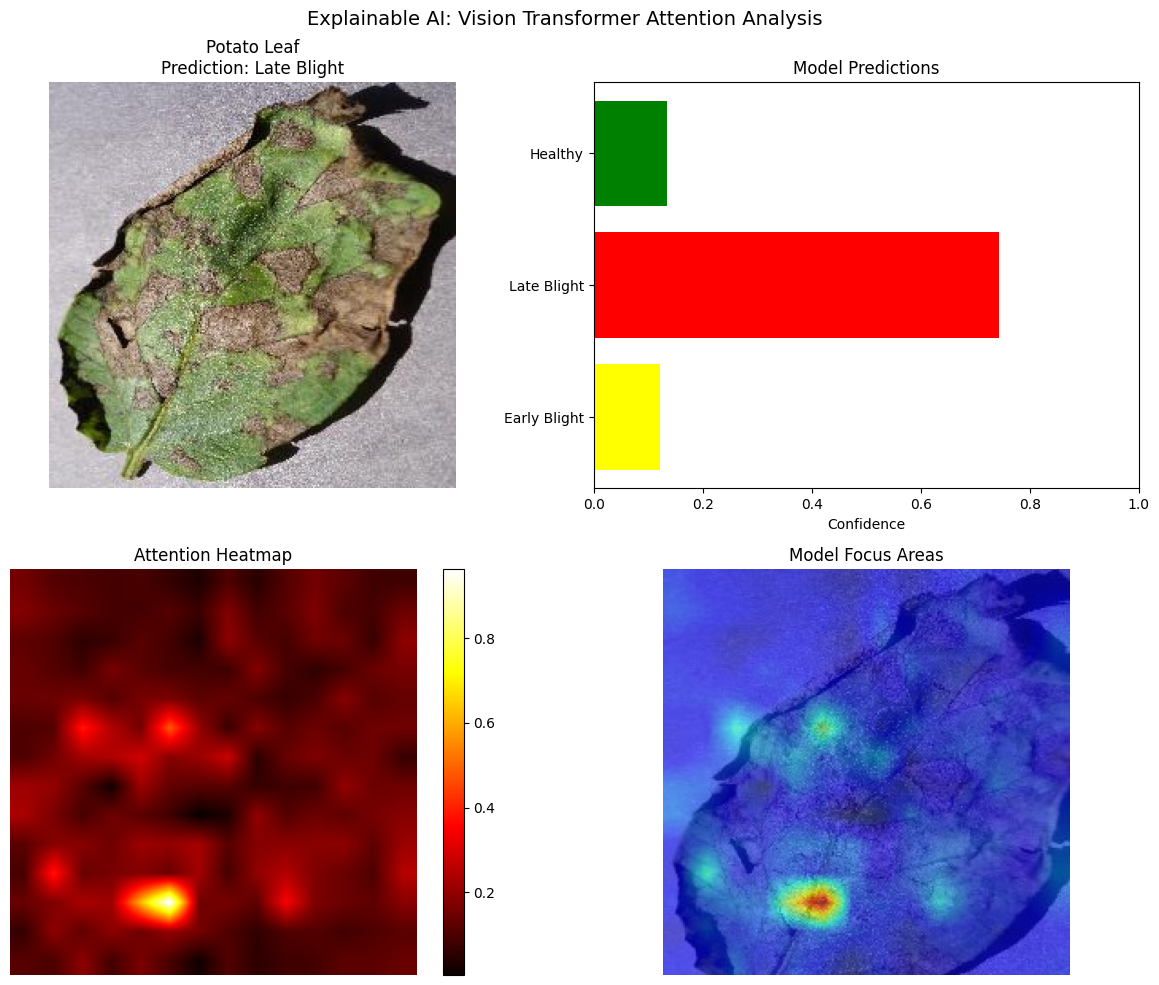


Model diagnosed: 1 with 74.31% confidence


In [17]:
# Create a comprehensive visualization for your XAI research
def create_xai_heatmap(image, attentions_list, model, input_tensor):
    """
    Create an explainable AI heatmap for potato disease classification
    """
    # Get model prediction
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)[0]
        prediction = torch.argmax(output, dim=1).item()
    
    # Class names (update these based on your classes)
    class_names = ['Early Blight', 'Late Blight', 'Healthy']  # Adjust order as needed
    
    # Get attention from last layer
    final_attention = attentions_list[-1][0, 0, 1:]  # [196]
    
    # Reshape to 14x14
    attention_map = final_attention.reshape(14, 14).numpy()
    
    # Normalize
    attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
    
    # Resize to image size
    attention_map_resized = cv2.resize(attention_map, (224, 224))
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Original image
    axes[0, 0].imshow(image)
    axes[0, 0].set_title(f'Potato Leaf\nPrediction: {class_names[prediction]}', fontsize=12)
    axes[0, 0].axis('off')
    
    # Confidence bar chart
    axes[0, 1].barh(class_names, probabilities.numpy(), color=['yellow', 'red', 'green'])
    axes[0, 1].set_xlabel('Confidence')
    axes[0, 1].set_title('Model Predictions')
    axes[0, 1].set_xlim(0, 1)
    
    # Attention heatmap
    im = axes[1, 0].imshow(attention_map_resized, cmap='hot')
    axes[1, 0].set_title('Attention Heatmap', fontsize=12)
    axes[1, 0].axis('off')
    plt.colorbar(im, ax=axes[1, 0])
    
    # Overlay
    axes[1, 1].imshow(image)
    axes[1, 1].imshow(attention_map_resized, cmap='jet', alpha=0.6)
    axes[1, 1].set_title('Model Focus Areas', fontsize=12)
    axes[1, 1].axis('off')
    
    plt.suptitle('Explainable AI: Vision Transformer Attention Analysis', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return prediction, probabilities.numpy()

# Create the XAI visualization
prediction, confidence = create_xai_heatmap(image, attentions_list, model, input_tensor)
print(f"\nModel diagnosed: {prediction} with {confidence[prediction]:.2%} confidence")